# Figure for slides

Notebook for the course [Master Hyperparameter Optimization for Tabular Learning](http://www.trainindata.com/p/master-hyperparameter-optimization-for-tabular-learning)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [2]:
# if you want more information about the dataset for this demo:

# scikit-learn dataset
# https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset

# this is a regression problem to predict disease progression

# load dataset
X, y = load_diabetes(return_X_y=True, as_frame=True)

X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [3]:
# random forests
rf_model = RandomForestRegressor(random_state=0, n_jobs=-1)

# hyperparameter space
rf_param_grid = dict(
    n_estimators=[10, 20, 50, 100, 200, 500, 1000, 2000],
    max_depth=[1, 2, 3, 4],
)

# search
reg = GridSearchCV(rf_model,
                   rf_param_grid,
                   scoring='neg_mean_squared_error',
                   cv=5)

search = reg.fit(X, y)

# best hyperparameters
search.best_params_

{'max_depth': 4, 'n_estimators': 2000}

In [4]:
results = pd.DataFrame(search.cv_results_)[['params', 'mean_test_score']]

results.head()

,params,mean_test_score
0,"{'max_depth': 1, 'n_estimators': 10}",-3891.305592
1,"{'max_depth': 1, 'n_estimators': 20}",-3893.071727
2,"{'max_depth': 1, 'n_estimators': 50}",-3853.357396
3,"{'max_depth': 1, 'n_estimators': 100}",-3874.385429
4,"{'max_depth': 1, 'n_estimators': 200}",-3876.155585


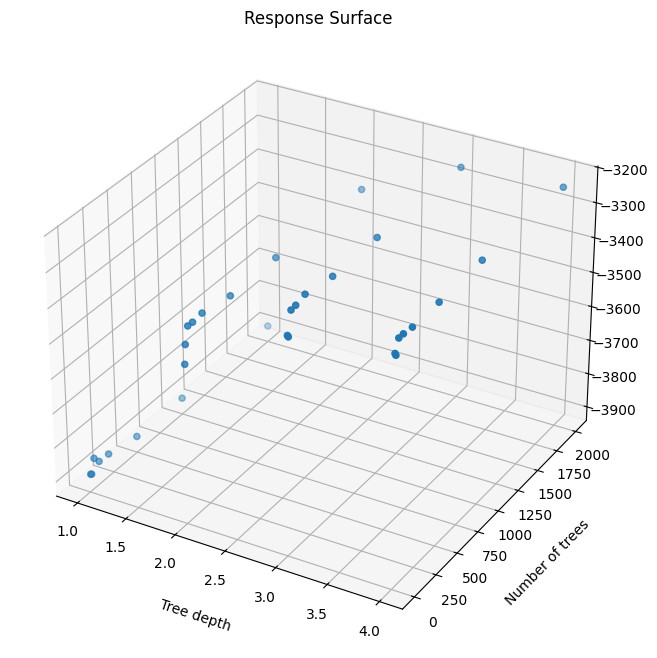

In [5]:
fig = plt.figure(figsize=(8, 8))

# syntax for 3-D projection
ax = plt.axes(projection='3d')

# depth
x = [1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
     3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4]

# number of trees
y = [10, 20, 50, 100, 200, 500, 1000, 2000, 10, 20, 50, 100, 200, 500, 1000, 2000,
     10, 20, 50, 100, 200, 500, 1000, 2000, 10, 20, 50, 100, 200, 500, 1000, 2000]

# performance
z = results['mean_test_score']

# plotting
ax.scatter(x, y, z,)
ax.set_title('Response Surface')
ax.set_xlabel('Tree depth', labelpad=12)
ax.set_ylabel('Number of trees', labelpad=12)
ax.set_zlabel('negative MSE', labelpad=12)
plt.savefig('01-response-surface.png', dpi=320, bbox_inches='tight')
plt.show()

The more parameters we optimize, the more complex the response surface becomes.